In [1]:
# ==========================================
# Phase 2: Exploratory Data Analysis
# Customer Churn Prediction
# ==========================================

import pandas as pd
import numpy as np
import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Connect to SQLite database
conn = sqlite3.connect("churn.db")

print("Connected to SQLite database successfully!")

Connected to SQLite database successfully!


In [3]:
customers = pd.read_sql_query(
    "SELECT * FROM customers",
    conn
)

accounts = pd.read_sql_query(
    "SELECT * FROM accounts",
    conn
)

services = pd.read_sql_query(
    "SELECT * FROM services",
    conn
)

churn_status = pd.read_sql_query(
    "SELECT * FROM churn_status",
    conn
)

print("Customers:", customers.shape)
print("Accounts:", accounts.shape)
print("Services:", services.shape)
print("Churn Status:", churn_status.shape)

Customers: (7043, 6)
Accounts: (7043, 6)
Services: (7043, 10)
Churn Status: (7043, 2)


In [4]:
# Merge customers with accounts
eda_df = customers.merge(
    accounts,
    on="customerID",
    how="inner"
)

# Merge services
eda_df = eda_df.merge(
    services,
    on="customerID",
    how="inner"
)

# Merge churn status
eda_df = eda_df.merge(
    churn_status,
    on="customerID",
    how="inner"
)

print("Final EDA dataset shape:", eda_df.shape)

Final EDA dataset shape: (7043, 21)


In [5]:
display(eda_df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,...,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Churn
0,7590-VHVEG,Female,0,Yes,No,1,Month-to-month,Yes,Electronic check,29.85,...,No,No phone service,DSL,No,Yes,No,No,No,No,No
1,5575-GNVDE,Male,0,No,No,34,One year,No,Mailed check,56.95,...,Yes,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,Male,0,No,No,2,Month-to-month,Yes,Mailed check,53.85,...,Yes,No,DSL,Yes,Yes,No,No,No,No,Yes
3,7795-CFOCW,Male,0,No,No,45,One year,No,Bank transfer (automatic),42.30,...,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,No
4,9237-HQITU,Female,0,No,No,2,Month-to-month,Yes,Electronic check,70.70,...,Yes,No,Fiber optic,No,No,No,No,No,No,Yes


In [6]:
eda_df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,...,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,One year,Yes,Mailed check,84.80,...,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,No
7039,2234-XADUH,Female,0,Yes,Yes,72,One year,Yes,Credit card (automatic),103.20,...,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,Month-to-month,Yes,Electronic check,29.60,...,No,No phone service,DSL,Yes,No,No,No,No,No,No
7041,8361-LTMKD,Male,1,Yes,No,4,Month-to-month,Yes,Mailed check,74.40,...,Yes,Yes,Fiber optic,No,No,No,No,No,No,Yes
7042,3186-AJIEK,Male,0,No,No,66,Two year,Yes,Bank transfer (automatic),105.65,...,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,No


In [7]:
print("Number of columns:", len(eda_df.columns))

print("\nColumns:")
for column in eda_df.columns:
    print(column)

Number of columns: 21

Columns:
customerID
gender
SeniorCitizen
Partner
Dependents
tenure
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Churn


In [8]:
eda_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   Contract          7043 non-null   object 
 7   PaperlessBilling  7043 non-null   object 
 8   PaymentMethod     7043 non-null   object 
 9   MonthlyCharges    7043 non-null   float64
 10  TotalCharges      7043 non-null   object 
 11  PhoneService      7043 non-null   object 
 12  MultipleLines     7043 non-null   object 
 13  InternetService   7043 non-null   object 
 14  OnlineSecurity    7043 non-null   object 
 15  OnlineBackup      7043 non-null   object 
 16  DeviceProtection  7043 non-null   object 


In [9]:
missing_values = pd.DataFrame({
    "Missing Values": eda_df.isnull().sum(),
    "Percentage": (eda_df.isnull().sum() / len(eda_df) * 100).round(2)
})

missing_values = missing_values[
    missing_values["Missing Values"] > 0
]

display(missing_values)

,Missing Values,Percentage


In [10]:
duplicate_ids = eda_df["customerID"].duplicated().sum()

print("Duplicate customer IDs:", duplicate_ids)

Duplicate customer IDs: 0


In [11]:
duplicate_rows = eda_df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


In [12]:
print(eda_df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Churn                object
dtype: object


In [13]:
eda_df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [14]:
churn_counts = eda_df["Churn"].value_counts()

display(churn_counts)

,count
Churn,
No,5174
Yes,1869


In [15]:
churn_percentage = (
    eda_df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(churn_percentage)

,proportion
Churn,
No,73.46
Yes,26.54


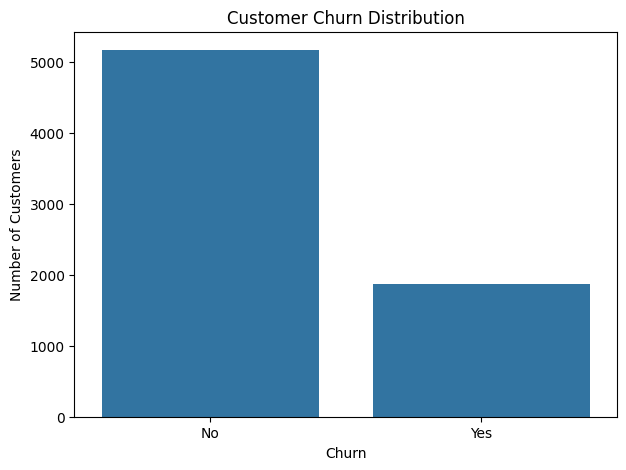

In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=eda_df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

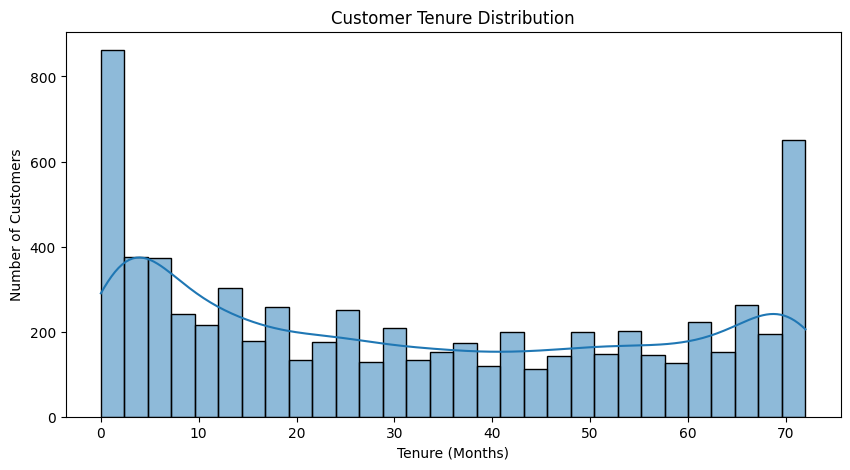

In [17]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=eda_df,
    x="tenure",
    bins=30,
    kde=True
)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

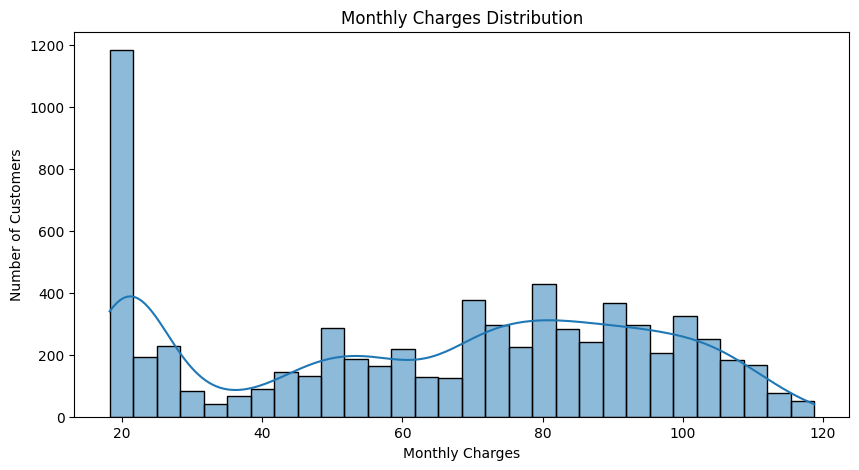

In [18]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=eda_df,
    x="MonthlyCharges",
    bins=30,
    kde=True
)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

In [19]:
print("TotalCharges data type:", eda_df["TotalCharges"].dtype)

print("\nBlank TotalCharges:")
print((eda_df["TotalCharges"].astype(str).str.strip() == "").sum())

TotalCharges data type: object

Blank TotalCharges:
11


In [20]:
eda_df[
    eda_df["TotalCharges"].astype(str).str.strip() == ""
][
    ["customerID", "tenure", "TotalCharges", "Churn"]
]

,customerID,tenure,TotalCharges,Churn
488,4472-LVYGI,0,,No
753,3115-CZMZD,0,,No
936,5709-LVOEQ,0,,No
1082,4367-NUYAO,0,,No
1340,1371-DWPAZ,0,,No
3331,7644-OMVMY,0,,No
3826,3213-VVOLG,0,,No
4380,2520-SGTTA,0,,No
5218,2923-ARZLG,0,,No
6670,4075-WKNIU,0,,No


In [21]:
contract_churn = pd.crosstab(
    eda_df["Contract"],
    eda_df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


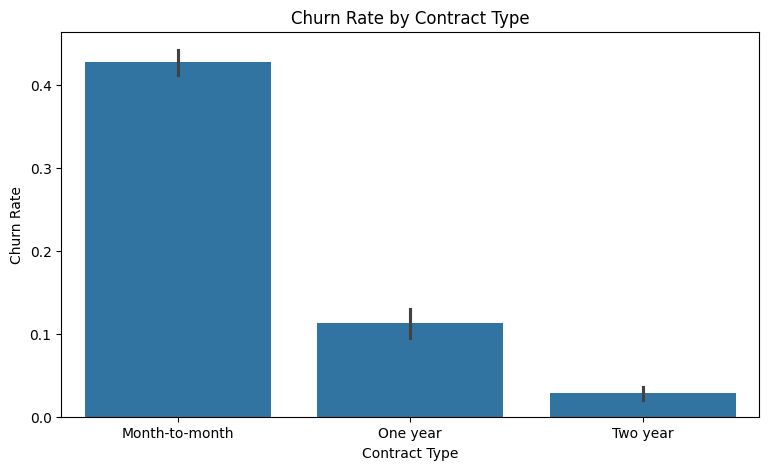

In [22]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=eda_df,
    x="Contract",
    y=eda_df["Churn"].eq("Yes")
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")

plt.show()

In [23]:
internet_churn = pd.crosstab(
    eda_df["InternetService"],
    eda_df["Churn"],
    normalize="index"
) * 100

display(internet_churn)

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


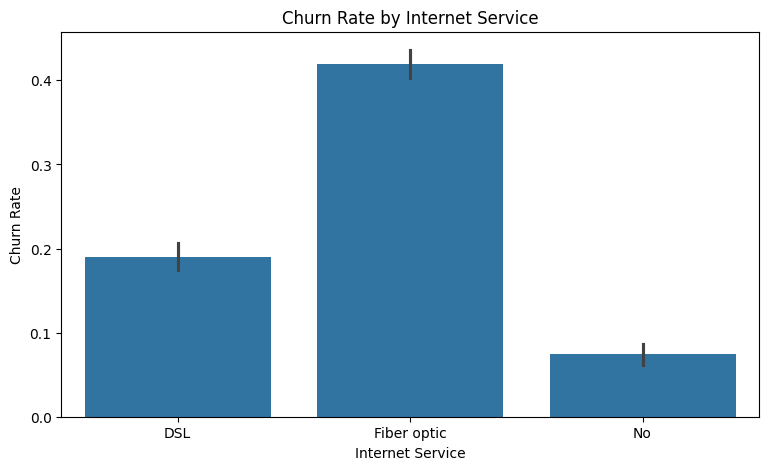

In [24]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=eda_df,
    x="InternetService",
    y=eda_df["Churn"].eq("Yes")
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate")

plt.show()

In [25]:
payment_churn = pd.crosstab(
    eda_df["PaymentMethod"],
    eda_df["Churn"],
    normalize="index"
) * 100

display(payment_churn)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


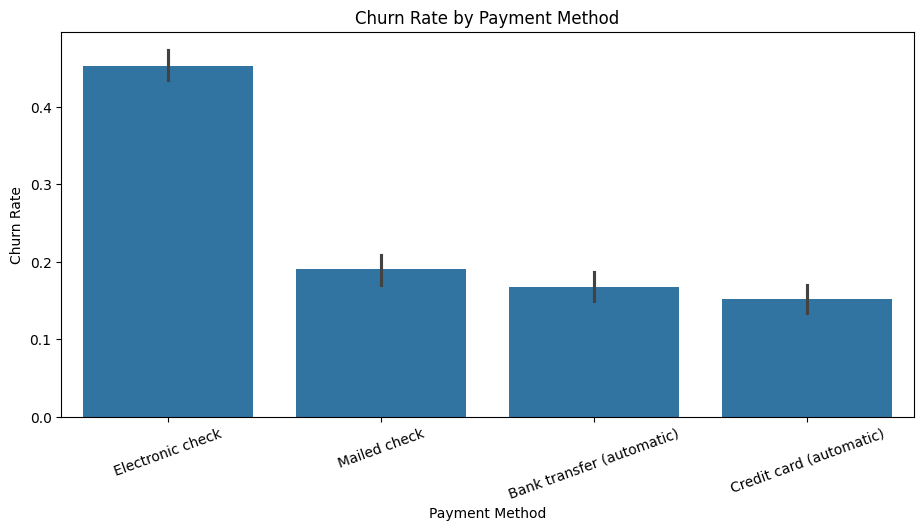

In [26]:
plt.figure(figsize=(11, 5))

sns.barplot(
    data=eda_df,
    x="PaymentMethod",
    y=eda_df["Churn"].eq("Yes")
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate")

plt.xticks(rotation=20)

plt.show()

### Data Quality Findings

The dataset contains 7,043 customer records and 21 variables. No duplicate customer IDs or duplicate rows were identified.

Although Pandas reports no standard missing values, further inspection found 11 blank values in the `TotalCharges` column. The `TotalCharges` column is currently stored as an object data type rather than a numeric type. Therefore, these blank entries represent a hidden data-quality issue that must be handled before machine learning.

The dataset does not contain duplicate customer records, which indicates that the customer identifier is unique in the dataset.

The `TotalCharges` issue will be handled during the feature engineering and preprocessing stage rather than modifying the data during the initial EDA.


In [27]:
blank_total = eda_df[
    eda_df["TotalCharges"].astype(str).str.strip() == ""
]

display(
    blank_total[
        ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
    ]
)

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [28]:
print("Blank TotalCharges records:", len(blank_total))
print("\nTenure values:")
print(blank_total["tenure"].value_counts())

print("\nChurn values:")
print(blank_total["Churn"].value_counts())

Blank TotalCharges records: 11

Tenure values:
tenure
0    11
Name: count, dtype: int64

Churn values:
Churn
No    11
Name: count, dtype: int64


### Investigation of Blank TotalCharges Values

A total of 11 records contain blank values in the `TotalCharges` column. Further investigation shows that all 11 customers have a tenure of 0 months and have not churned.

These records also contain valid `MonthlyCharges` values. Therefore, the blank `TotalCharges` values are associated with customers who are at the beginning of their service period rather than being randomly missing observations.

The 11 customers should not be removed from the dataset because they represent valid customer records. The `TotalCharges` column will be converted to numeric format during feature engineering, and an appropriate value will be assigned to these zero-tenure customers during preprocessing.


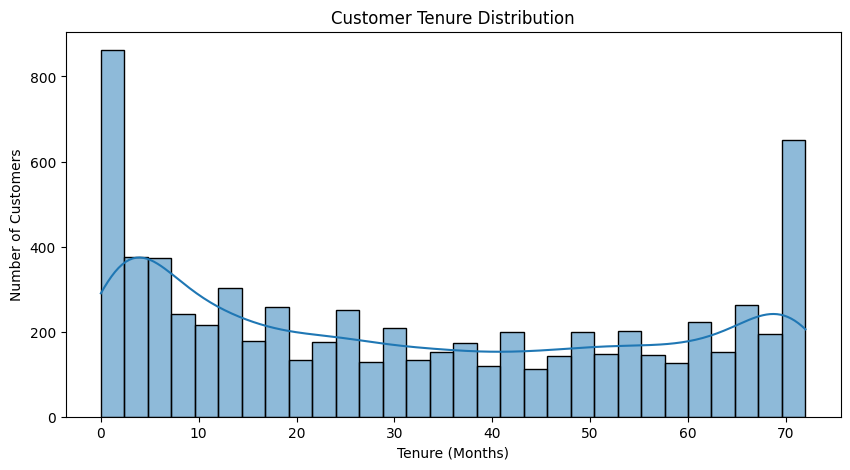

In [29]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=eda_df,
    x="tenure",
    bins=30,
    kde=True
)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

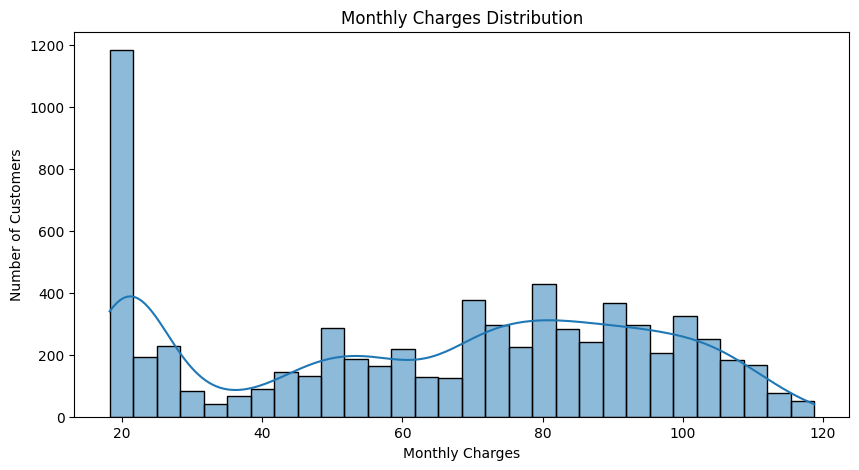

In [30]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=eda_df,
    x="MonthlyCharges",
    bins=30,
    kde=True
)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

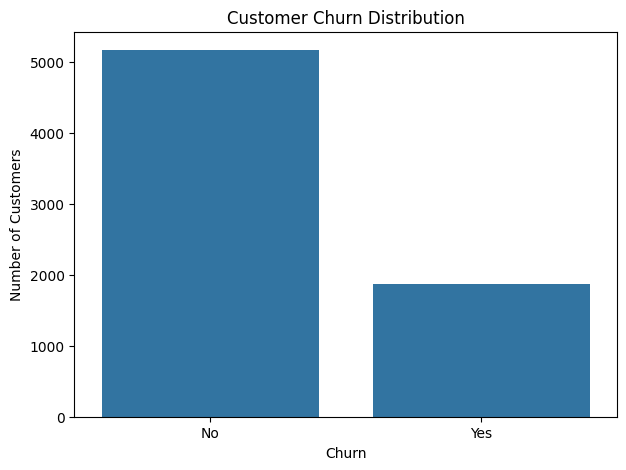

In [31]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=eda_df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

#EDA Part 2 — Churn Analysis

**Contract Type vs Churn**

In [32]:
contract_churn = pd.crosstab(
    eda_df["Contract"],
    eda_df["Churn"],
    normalize="index"
) * 100

contract_churn = contract_churn.round(2)

display(contract_churn)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


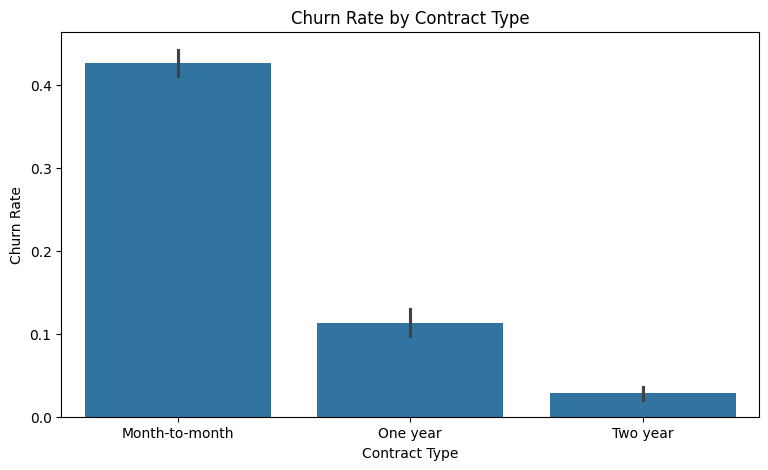

In [33]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=eda_df,
    x="Contract",
    y=eda_df["Churn"].eq("Yes").astype(int)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")

plt.show()

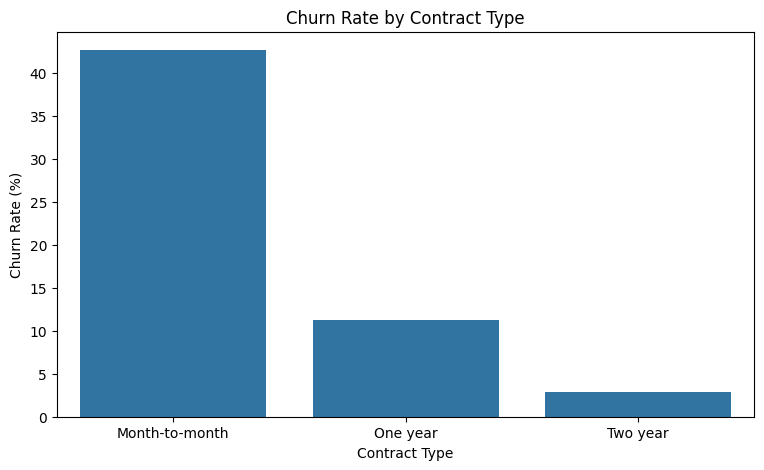

In [34]:
contract_plot = (
    eda_df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=contract_plot,
    x="Contract",
    y="ChurnRate"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.show()

### Observation

Month-to-month customers have the highest churn rate, while customers with one-year and two-year contracts have substantially lower churn rates. This suggests that longer contractual commitments are associated with better customer retention.

**Internet Service vs Churn**

In [35]:
internet_plot = (
    eda_df.groupby("InternetService")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

display(internet_plot)

,InternetService,ChurnRate
0,DSL,18.959108
1,Fiber optic,41.892765
2,No,7.404980


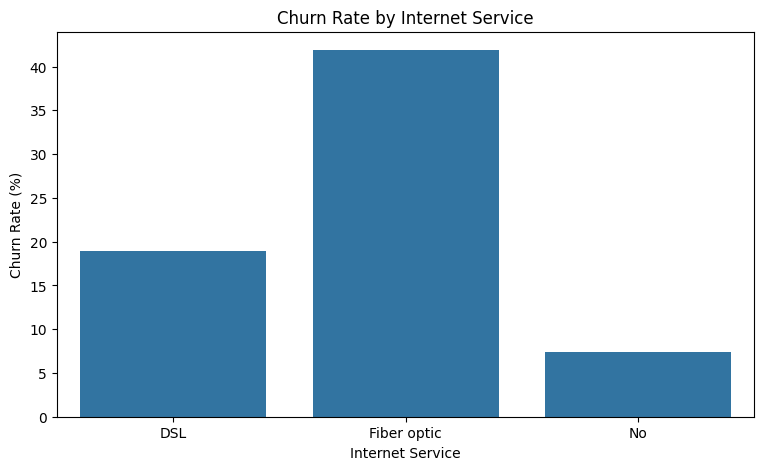

In [36]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=internet_plot,
    x="InternetService",
    y="ChurnRate"
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

plt.show()

### Observation

Fiber optic customers show a substantially higher churn rate than DSL and customers without internet service. This makes InternetService an important variable for further investigation and machine learning.

**Payment Method vs Churn**

In [37]:
payment_plot = (
    eda_df.groupby("PaymentMethod")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

display(payment_plot)

,PaymentMethod,ChurnRate
0,Bank transfer (automatic),16.709845
1,Credit card (automatic),15.243101
2,Electronic check,45.285412
3,Mailed check,19.106700


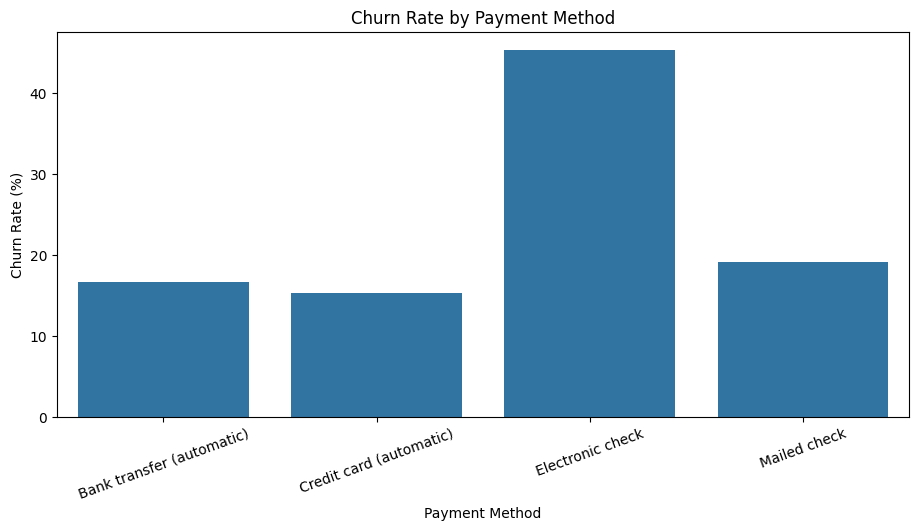

In [38]:
plt.figure(figsize=(11, 5))

sns.barplot(
    data=payment_plot,
    x="PaymentMethod",
    y="ChurnRate"
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=20)

plt.show()

### Observation

Electronic check users have the highest churn rate among the payment methods. Customers using automatic payment methods show considerably lower churn rates. PaymentMethod therefore appears to be an important factor associated with customer churn.

**Technical Support vs Churn**

In [39]:
support_plot = (
    eda_df.groupby("TechSupport")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

display(support_plot)

,TechSupport,ChurnRate
0,No,41.635474
1,No internet service,7.404980
2,Yes,15.166341


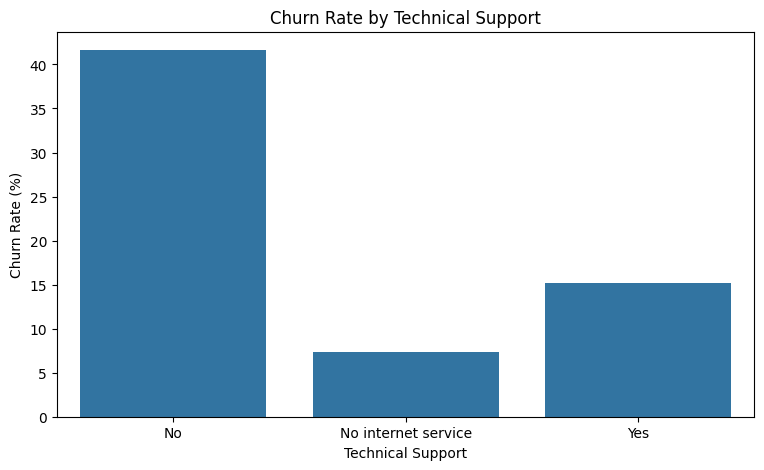

In [40]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=support_plot,
    x="TechSupport",
    y="ChurnRate"
)

plt.title("Churn Rate by Technical Support")
plt.xlabel("Technical Support")
plt.ylabel("Churn Rate (%)")

plt.show()

### Observation

Customers without technical support have a considerably higher churn rate than customers who have technical support. This suggests that providing technical support may be associated with improved customer retention.

**Online Security vs Churn**

In [41]:
security_plot = (
    eda_df.groupby("OnlineSecurity")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

display(security_plot)

,OnlineSecurity,ChurnRate
0,No,41.766724
1,No internet service,7.404980
2,Yes,14.611194


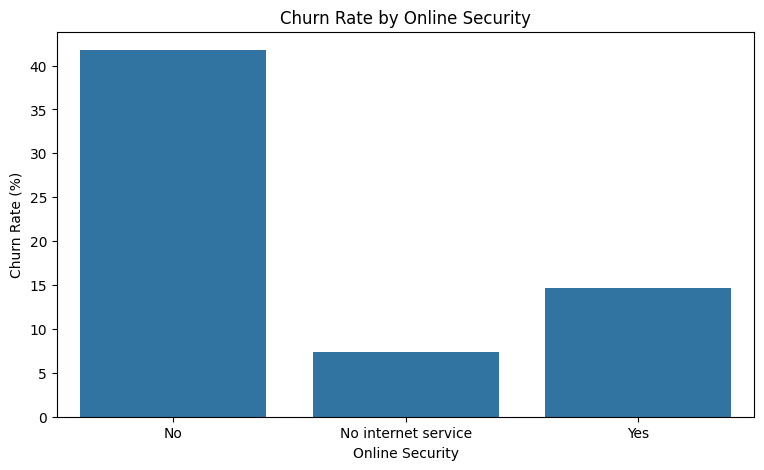

In [42]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=security_plot,
    x="OnlineSecurity",
    y="ChurnRate"
)

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")

plt.show()

**Online Backup vs Churn**

In [43]:
backup_plot = (
    eda_df.groupby("OnlineBackup")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

display(backup_plot)

,OnlineBackup,ChurnRate
0,No,39.928756
1,No internet service,7.404980
2,Yes,21.531494


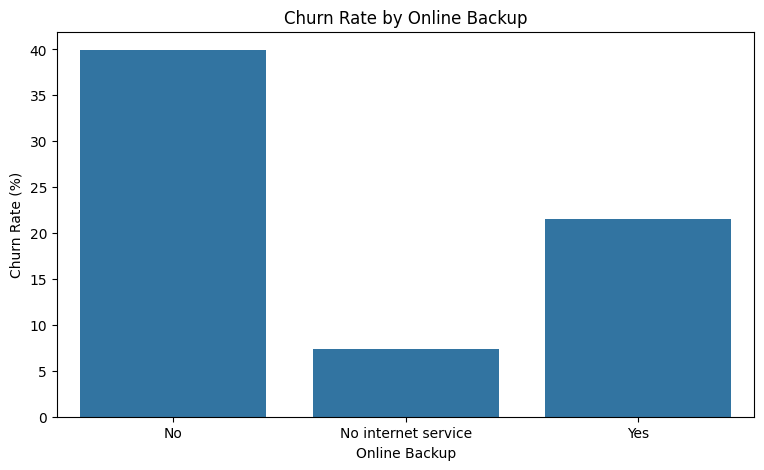

In [44]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=backup_plot,
    x="OnlineBackup",
    y="ChurnRate"
)

plt.title("Churn Rate by Online Backup")
plt.xlabel("Online Backup")
plt.ylabel("Churn Rate (%)")

plt.show()

**Device Protection vs Churn**

In [45]:
device_plot = (
    eda_df.groupby("DeviceProtection")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

display(device_plot)

,DeviceProtection,ChurnRate
0,No,39.127625
1,No internet service,7.404980
2,Yes,22.502064


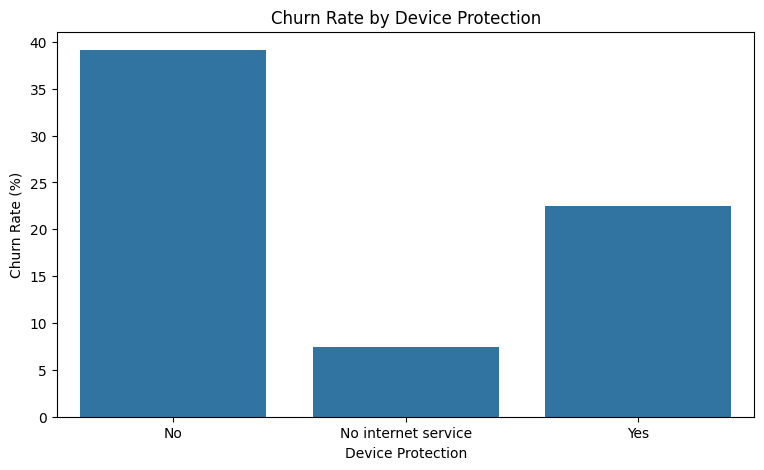

In [46]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=device_plot,
    x="DeviceProtection",
    y="ChurnRate"
)

plt.title("Churn Rate by Device Protection")
plt.xlabel("Device Protection")
plt.ylabel("Churn Rate (%)")

plt.show()

**Streaming TV vs Churn**

In [47]:
tv_plot = (
    eda_df.groupby("StreamingTV")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

display(tv_plot)

,StreamingTV,ChurnRate
0,No,33.523132
1,No internet service,7.404980
2,Yes,30.070188


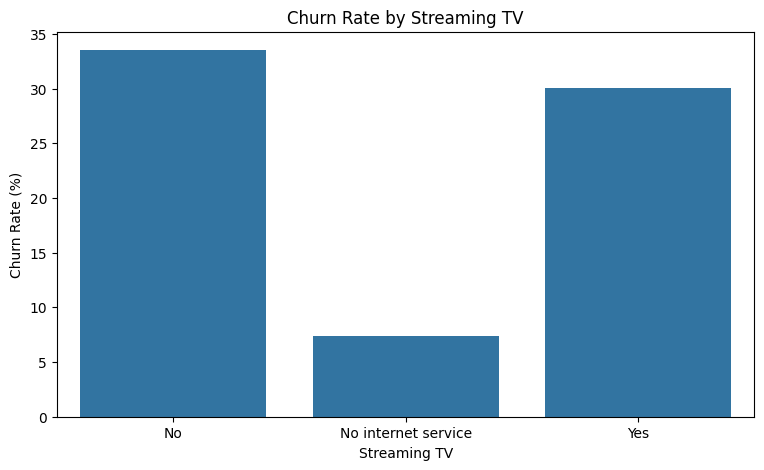

In [48]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=tv_plot,
    x="StreamingTV",
    y="ChurnRate"
)

plt.title("Churn Rate by Streaming TV")
plt.xlabel("Streaming TV")
plt.ylabel("Churn Rate (%)")

plt.show()

**Streaming Movies vs Churn**

In [49]:
movies_plot = (
    eda_df.groupby("StreamingMovies")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

display(movies_plot)

,StreamingMovies,ChurnRate
0,No,33.680431
1,No internet service,7.404980
2,Yes,29.941435


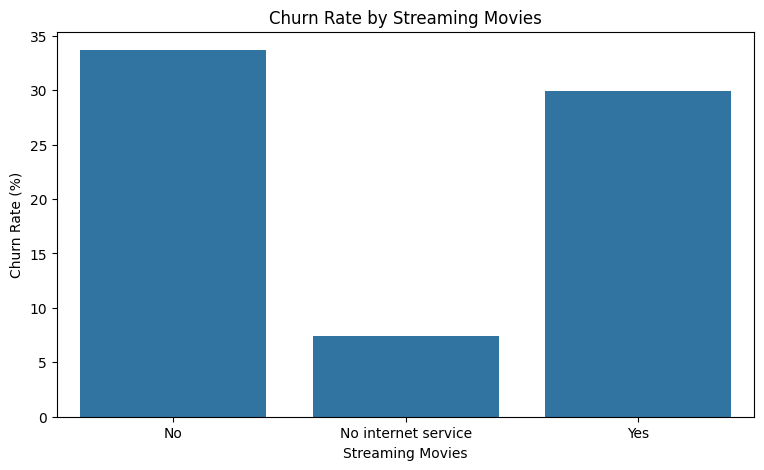

In [50]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=movies_plot,
    x="StreamingMovies",
    y="ChurnRate"
)

plt.title("Churn Rate by Streaming Movies")
plt.xlabel("Streaming Movies")
plt.ylabel("Churn Rate (%)")

plt.show()

**Tenure vs Churn**

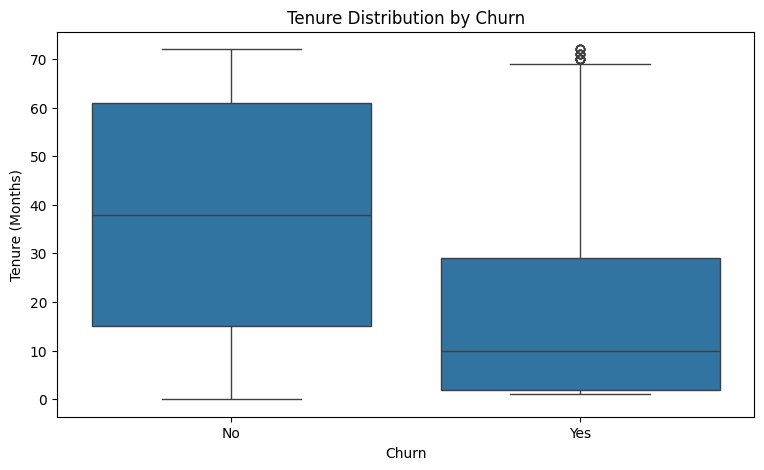

In [51]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=eda_df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

In [52]:
eda_df.groupby("Churn")["tenure"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
Churn,,,,,
No,5174,37.57,38.0,0,72
Yes,1869,17.98,10.0,1,72


### Observation

Churned customers generally have shorter tenure than retained customers. This indicates that newer customers may be more vulnerable to churn, making the early customer lifecycle an important period for retention strategies.

**Monthly Charges vs Churn**

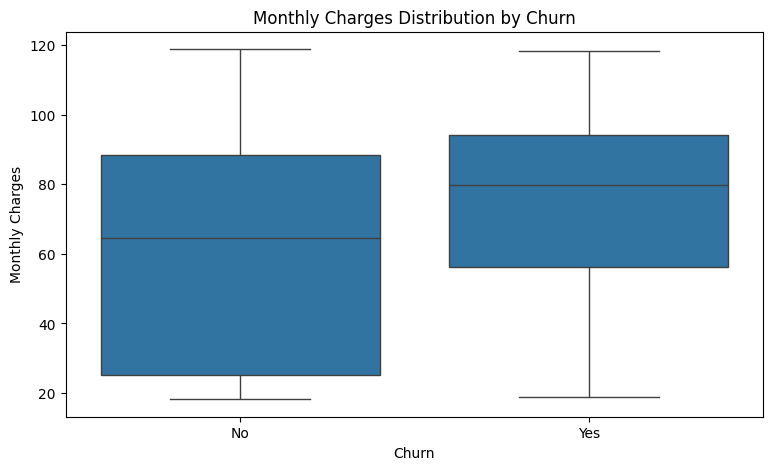

In [53]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=eda_df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [54]:
eda_df.groupby("Churn")["MonthlyCharges"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
Churn,,,,,
No,5174,61.27,64.43,18.25,118.75
Yes,1869,74.44,79.65,18.85,118.35


### Observation

Churned customers generally have higher monthly charges than retained customers. This suggests that monthly pricing or the services associated with higher charges may contribute to customer churn.

**Gender vs Churn**

In [55]:
gender_plot = (
    eda_df.groupby("gender")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

display(gender_plot)

,gender,ChurnRate
0,Female,26.920872
1,Male,26.160338


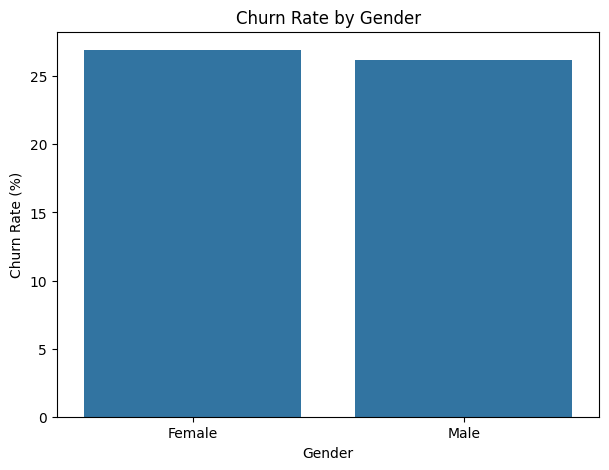

In [56]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=gender_plot,
    x="gender",
    y="ChurnRate"
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

plt.show()

**Partner Status vs Churn**

In [57]:
partner_plot = (
    eda_df.groupby("Partner")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

display(partner_plot)

,Partner,ChurnRate
0,No,32.957979
1,Yes,19.664903


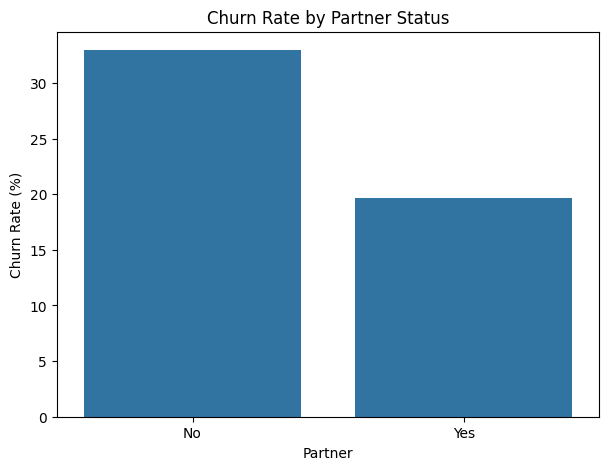

In [58]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=partner_plot,
    x="Partner",
    y="ChurnRate"
)

plt.title("Churn Rate by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Churn Rate (%)")

plt.show()

**Dependents vs Churn**

In [59]:
dependent_plot = (
    eda_df.groupby("Dependents")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

display(dependent_plot)

,Dependents,ChurnRate
0,No,31.279140
1,Yes,15.450237


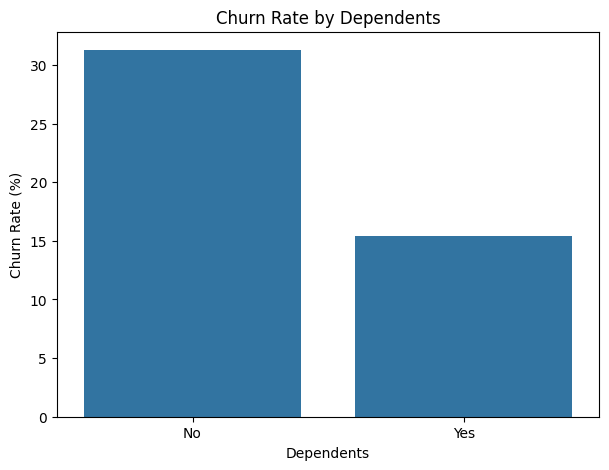

In [60]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=dependent_plot,
    x="Dependents",
    y="ChurnRate"
)

plt.title("Churn Rate by Dependents")
plt.xlabel("Dependents")
plt.ylabel("Churn Rate (%)")

plt.show()

**Senior Citizen vs Churn**

In [61]:
senior_plot = (
    eda_df.groupby("SeniorCitizen")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

display(senior_plot)

,SeniorCitizen,ChurnRate
0,0,23.606168
1,1,41.681261


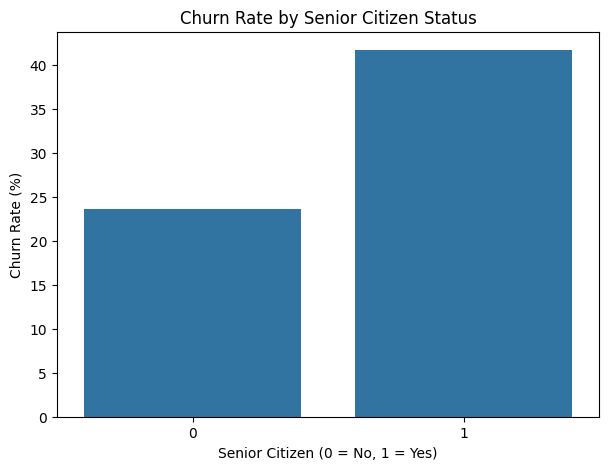

In [62]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=senior_plot,
    x="SeniorCitizen",
    y="ChurnRate"
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate (%)")

plt.show()

#EDA Part 3

**Prepare Numeric Variables**

In [63]:
eda_corr = eda_df.copy()

eda_corr["TotalCharges"] = pd.to_numeric(
    eda_corr["TotalCharges"],
    errors="coerce"
)

# Encode Churn
eda_corr["Churn_encoded"] = eda_corr["Churn"].map({
    "No": 0,
    "Yes": 1
})

print(eda_corr[[
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn_encoded"
]].dtypes)

tenure              int64
MonthlyCharges    float64
TotalCharges      float64
Churn_encoded       int64
dtype: object


**Correlation Matrix**

In [64]:
corr_data = eda_corr[
    [
        "SeniorCitizen",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Churn_encoded"
    ]
]

correlation_matrix = corr_data.corr()

display(correlation_matrix.round(2))

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn_encoded
SeniorCitizen,1.00,0.02,0.22,0.10,0.15
tenure,0.02,1.00,0.25,0.83,-0.35
MonthlyCharges,0.22,0.25,1.00,0.65,0.19
TotalCharges,0.10,0.83,0.65,1.00,-0.20
Churn_encoded,0.15,-0.35,0.19,-0.20,1.00


**Correlation Heatmap**

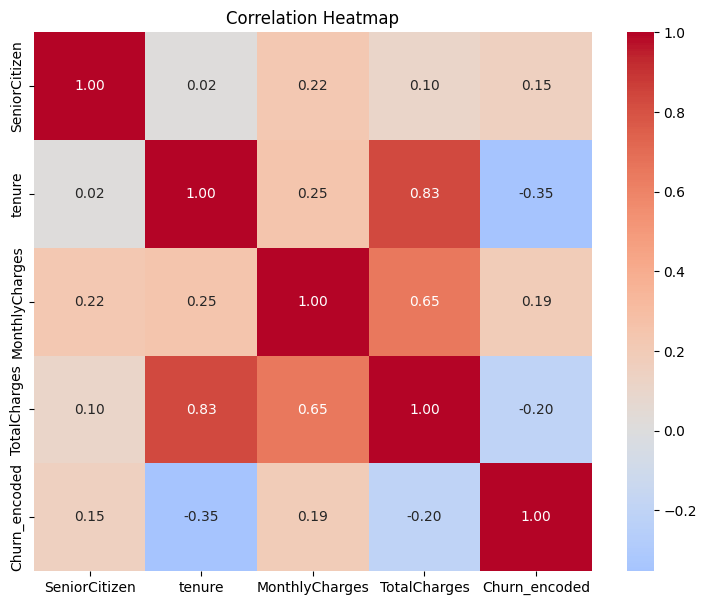

In [65]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

### Correlation Analysis

Correlation analysis was performed on the available numeric variables, including SeniorCitizen, tenure, MonthlyCharges, TotalCharges, and the encoded Churn variable.

The correlation matrix helps identify linear relationships between numerical variables and provides an initial indication of which numerical features may be associated with customer churn. Correlation does not establish causation, so the results will be considered together with the categorical and bivariate analysis.


**Correlation With Churn**

In [66]:
churn_correlation = (
    correlation_matrix["Churn_encoded"]
    .drop("Churn_encoded")
    .sort_values(ascending=False)
)

display(churn_correlation.round(3))

,Churn_encoded
MonthlyCharges,0.193
SeniorCitizen,0.151
TotalCharges,-0.199
tenure,-0.352


**Outlier Analysis — Monthly Charges**

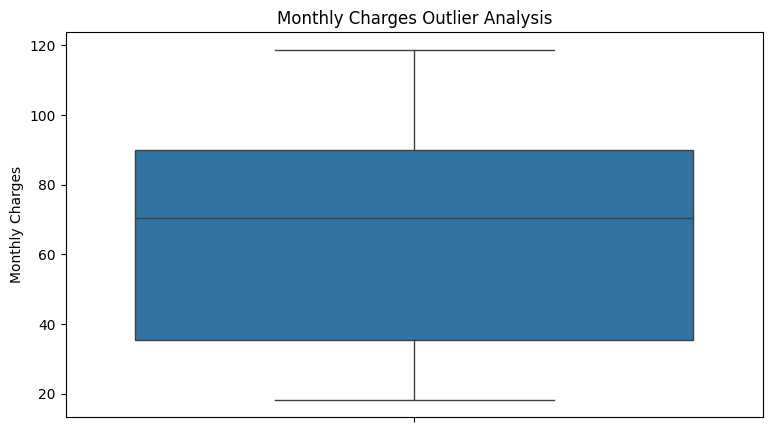

In [67]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=eda_corr,
    y="MonthlyCharges"
)

plt.title("Monthly Charges Outlier Analysis")
plt.ylabel("Monthly Charges")

plt.show()

In [68]:
Q1 = eda_corr["MonthlyCharges"].quantile(0.25)
Q3 = eda_corr["MonthlyCharges"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_monthly = eda_corr[
    (eda_corr["MonthlyCharges"] < lower_bound) |
    (eda_corr["MonthlyCharges"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of outliers:", len(outliers_monthly))

Q1: 35.5
Q3: 89.85
IQR: 54.349999999999994
Lower Bound: -46.02499999999999
Upper Bound: 171.375
Number of outliers: 0


**Outlier Analysis — Tenure**

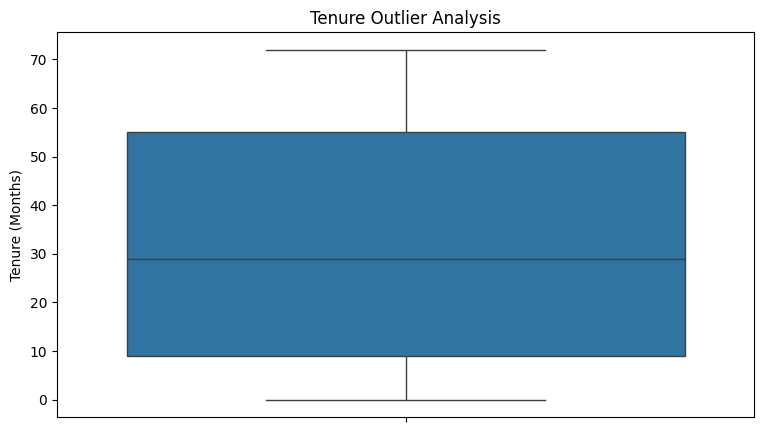

In [69]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=eda_corr,
    y="tenure"
)

plt.title("Tenure Outlier Analysis")
plt.ylabel("Tenure (Months)")

plt.show()

In [70]:
Q1_t = eda_corr["tenure"].quantile(0.25)
Q3_t = eda_corr["tenure"].quantile(0.75)

IQR_t = Q3_t - Q1_t

lower_t = Q1_t - 1.5 * IQR_t
upper_t = Q3_t + 1.5 * IQR_t

outliers_tenure = eda_corr[
    (eda_corr["tenure"] < lower_t) |
    (eda_corr["tenure"] > upper_t)
]

print("Q1:", Q1_t)
print("Q3:", Q3_t)
print("IQR:", IQR_t)
print("Lower Bound:", lower_t)
print("Upper Bound:", upper_t)
print("Number of outliers:", len(outliers_tenure))

Q1: 9.0
Q3: 55.0
IQR: 46.0
Lower Bound: -60.0
Upper Bound: 124.0
Number of outliers: 0


**Create Tenure Groups**

In [71]:
eda_df["tenure_group"] = pd.cut(
    eda_df["tenure"],
    bins=[-1, 12, 24, 48, float("inf")],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-48 months",
        "49+ months"
    ]
)

display(
    eda_df["tenure_group"].value_counts().sort_index()
)

,count
tenure_group,
0-12 months,2186
13-24 months,1024
25-48 months,1594
49+ months,2239


**Churn Rate by Tenure Group**

In [72]:
tenure_churn = (
    eda_df.groupby("tenure_group", observed=False)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

display(tenure_churn.round(2))

,tenure_group,ChurnRate
0,0-12 months,47.44
1,13-24 months,28.71
2,25-48 months,20.39
3,49+ months,9.51


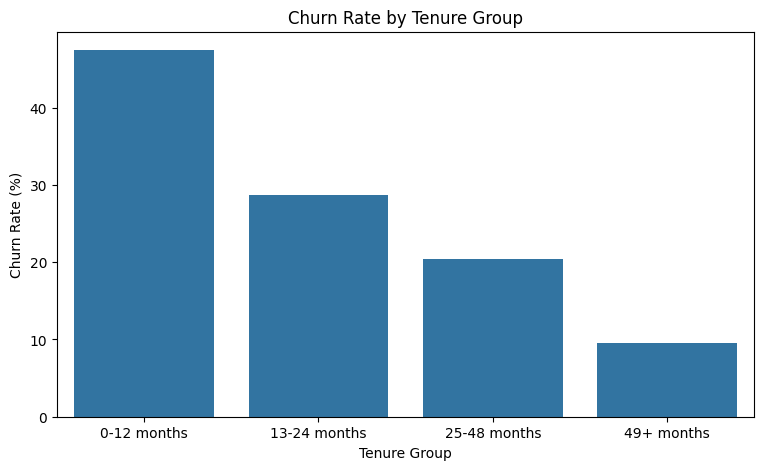

In [73]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=tenure_churn,
    x="tenure_group",
    y="ChurnRate"
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.show()

**Contract × Tenure Segmentation**

In [74]:
segment_analysis = (
    eda_df
    .groupby(
        ["Contract", "tenure_group"],
        observed=False
    )
    .agg(
        total_customers=("customerID", "count"),
        churned_customers=(
            "Churn",
            lambda x: (x == "Yes").sum()
        )
    )
    .reset_index()
)

segment_analysis["churn_rate"] = (
    segment_analysis["churned_customers"]
    / segment_analysis["total_customers"]
    * 100
)

segment_analysis = segment_analysis.sort_values(
    "churn_rate",
    ascending=False
)

display(segment_analysis.round(2))

,Contract,tenure_group,total_customers,churned_customers,churn_rate
0,Month-to-month,0-12 months,1994,1024,51.35
1,Month-to-month,13-24 months,737,278,37.72
2,Month-to-month,25-48 months,802,264,32.92
3,Month-to-month,49+ months,342,89,26.02
7,One year,49+ months,634,82,12.93
6,One year,25-48 months,518,55,10.62
4,One year,0-12 months,124,13,10.48
5,One year,13-24 months,197,16,8.12
11,Two year,49+ months,1263,42,3.33
10,Two year,25-48 months,274,6,2.19


**Visualize the Customer Segments**

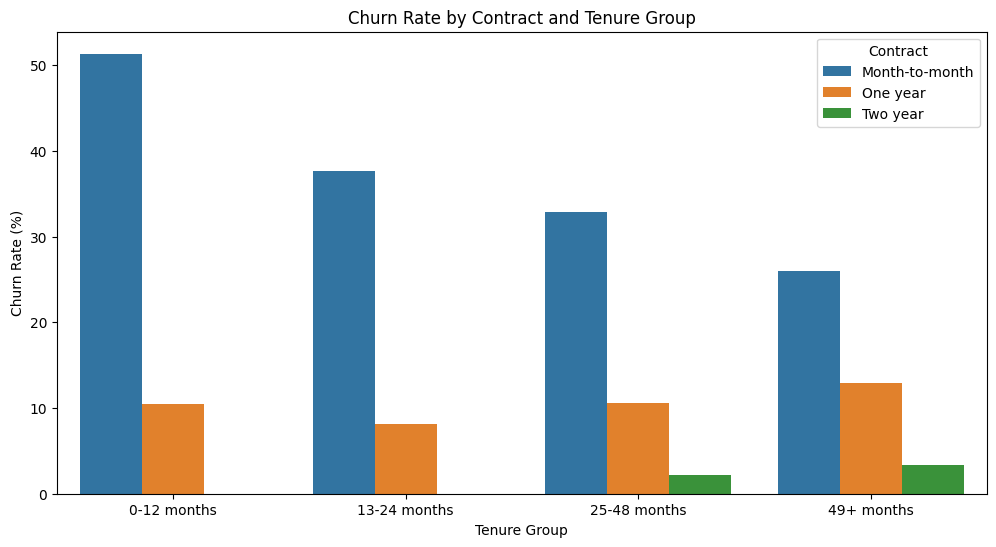

In [75]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=segment_analysis,
    x="tenure_group",
    y="churn_rate",
    hue="Contract"
)

plt.title("Churn Rate by Contract and Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.show()

**Find the Most At-Risk Segment**

In [76]:
highest_risk_segment = segment_analysis.iloc[0]

print("Highest-risk segment:")
print(highest_risk_segment)

Highest-risk segment:
Contract             Month-to-month
tenure_group            0-12 months
total_customers                1994
churned_customers              1024
churn_rate                51.354062
Name: 0, dtype: object


**Revenue at Risk by Segment**

In [77]:
segment_revenue = (
    eda_df
    .groupby(
        ["Contract", "tenure_group"],
        observed=False
    )
    .agg(
        total_customers=("customerID", "count"),
        churned_customers=(
            "Churn",
            lambda x: (x == "Yes").sum()
        ),
        monthly_revenue_at_risk=(
            "MonthlyCharges",
            lambda x: x[eda_df.loc[x.index, "Churn"] == "Yes"].sum()
        )
    )
    .reset_index()
)

segment_revenue["churn_rate"] = (
    segment_revenue["churned_customers"]
    / segment_revenue["total_customers"]
    * 100
)

segment_revenue = segment_revenue.sort_values(
    "monthly_revenue_at_risk",
    ascending=False
)

display(segment_revenue.round(2))

,Contract,tenure_group,total_customers,churned_customers,monthly_revenue_at_risk,churn_rate
0,Month-to-month,0-12 months,1994,1024,68301.45,51.35
2,Month-to-month,25-48 months,802,264,22557.00,32.92
1,Month-to-month,13-24 months,737,278,21980.30,37.72
3,Month-to-month,49+ months,342,89,8008.35,26.02
7,One year,49+ months,634,82,7842.95,12.93
6,One year,25-48 months,518,55,4521.35,10.62
11,Two year,49+ months,1263,42,3781.15,3.33
5,One year,13-24 months,197,16,1101.35,8.12
4,One year,0-12 months,124,13,652.80,10.48
10,Two year,25-48 months,274,6,384.15,2.19


**Identify Top Revenue-at-Risk Segments**

In [78]:
top_risk_segments = segment_revenue.head(5)

display(top_risk_segments.round(2))

,Contract,tenure_group,total_customers,churned_customers,monthly_revenue_at_risk,churn_rate
0,Month-to-month,0-12 months,1994,1024,68301.45,51.35
2,Month-to-month,25-48 months,802,264,22557.00,32.92
1,Month-to-month,13-24 months,737,278,21980.30,37.72
3,Month-to-month,49+ months,342,89,8008.35,26.02
7,One year,49+ months,634,82,7842.95,12.93


**Create a Simple High-Risk Customer Flag**

In [79]:
eda_df["high_risk_flag"] = (
    (eda_df["Contract"] == "Month-to-month") &
    (eda_df["tenure"] <= 12) &
    (eda_df["TechSupport"] == "No")
)

print(
    "Customers matching high-risk criteria:",
    eda_df["high_risk_flag"].sum()
)

Customers matching high-risk criteria: 1363


In [80]:
high_risk_summary = (
    eda_df
    .groupby("high_risk_flag")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

display(high_risk_summary.round(2))

,Churn
high_risk_flag,
False,18.26
True,61.04
